# Set up

## Change working directory

In [1]:
%cd ../

C:\Users\Skylar\Downloads\tools


C:\Users\Skylar\Downloads\tools\env\lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


## Install packages

In [2]:
# Placeholder

## Import development libraries

In [3]:
import hypothesis
import ipytest
from hypothesis import strategies as st
from pandera import pandas as pa
from sklearn import datasets as snds
from sklearn import model_selection as snmos
from tools import utils as tsus

ipytest.autoconfig(rewrite_asserts=False)

## Import other libraries

In [4]:
import typing

import numpy as np
import pandas as pd
import toolz as tz
from matplotlib import pyplot as plt
from sklearn import base as snbe
from sklearn import feature_selection as snfs

## Declare constants

In [5]:
module: str = "feature_engineering"

# Define InteractionEngineer

## Define

In [6]:
class InteractionEngineer(snbe.BaseEstimator, snbe.TransformerMixin):
    def __init__(
        self,
        first_feature: str,
        second_feature: str,
        is_classification: bool,
        operators: list | tuple = ("add", "sub", "rsub", "mul", "div", "rdiv"),
        mutual_info_args: dict | None = None,
    ) -> None:
        self.first_feature, self.second_feature = first_feature, second_feature
        self.is_classification = is_classification
        self.operators, self.mutual_info_args = operators, mutual_info_args

    def fit(self, X: pd.DataFrame, y: pd.Series) -> "InteractionEngineer":
        self.initial_features: pd.Index = X.columns
        self.assign_args: dict[str, typing.Callable] = self._get_assign_args()
        X_engineered: pd.DataFrame = self._engineer_features(X=X)
        self.mutual_info: pd.Series = self._get_mutual_information(X_engineered=X_engineered, y=y)
        self.best_engineered_feature: str = self._get_best_engineered_feature()
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        return X.assign(**tz.keyfilter(predicate=lambda x: x == self.best_engineered_feature, d=self.assign_args))

    def get_feature_names_out(self) -> list[str]:
        return self.initial_features.tolist() + [self.best_engineered_feature]

    def plot(self, **kwargs) -> plt.Axes:
        filtered_kwargs: dict[str, typing.Any] = tz.keyfilter(predicate=lambda x: x not in ["kind"], d=kwargs)
        return self.mutual_info.iloc[::-1].plot(kind="barh", **filtered_kwargs)

    def _name_engineered_feature(self, operator: str) -> str:
        return "%s_%s_%s" % (self.first_feature, operator, self.second_feature)

    def _engineer_feature(self, operator: str) -> typing.Callable:
        def engineer_feature(X: pd.DataFrame) -> pd.Series:
            eps: float = np.finfo(dtype=float).eps
            first_feature: pd.Series = X[self.first_feature].pipe(
                func=lambda x: x.add(other=eps) if operator == "rdiv" else x
            )
            second_feature: pd.Series = X[self.second_feature].pipe(
                func=lambda x: x.add(other=eps) if operator == "div" else x
            )
            return getattr(first_feature, operator)(other=second_feature)

        return engineer_feature

    def _get_assign_args(self) -> dict[str, typing.Callable]:
        return tz.pipe(
            self.operators,
            tz.curried.map(lambda x: [self._name_engineered_feature(operator=x), self._engineer_feature(operator=x)]),
            dict,
        )

    def _engineer_features(self, X: pd.DataFrame) -> pd.DataFrame:
        return X.loc[:, [self.first_feature, self.second_feature]].assign(**self.assign_args)

    def _get_mutual_information(self, X_engineered: pd.DataFrame, y: pd.Series) -> pd.Series:
        mutual_info: typing.Callable = (
            snfs.mutual_info_classif if self.is_classification else snfs.mutual_info_regression
        )
        mutual_info_args: dict = self.mutual_info_args.copy() if self.mutual_info_args else {}
        mutual_info_args.setdefault("random_state", 0)
        return pd.Series(
            data=mutual_info(X=X_engineered, y=y, **mutual_info_args), index=X_engineered.columns, name="mutual_info"
        ).sort_values(ascending=False)

    def _get_best_engineered_feature(self) -> str:
        return self.mutual_info.drop(labels=[self.first_feature, self.second_feature]).nlargest(n=1).index[0]

## Demonstrate

<class 'tuple'> with 2 elements
- element: 0
  (<class 'pandas.core.frame.DataFrame'>, (48842, 14))
- element: 1
  (<class 'pandas.core.series.Series'>, (48842,))
<class 'list'> with 4 elements
- element: 0
  (<class 'pandas.core.frame.DataFrame'>, (39073, 14))
- element: 1
  (<class 'pandas.core.frame.DataFrame'>, (9769, 14))
- element: 2
  (<class 'pandas.core.series.Series'>, (39073,))
- element: 3
  (<class 'pandas.core.series.Series'>, (9769,))


,capital_gain,capital_loss,capital_gain_sub_capital_loss
18478,0,0,0
23318,0,0,0
36914,0,0,0
6149,0,0,0
42736,0,2042,-2042
...,...,...,...
10727,0,1579,-1579
46736,0,0,0
14991,0,0,0
2942,0,0,0


<Axes: >

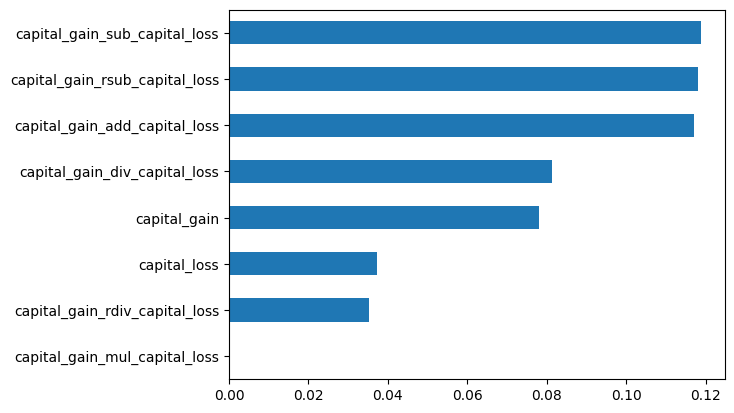

In [7]:
# Get data
X, y = data = snds.fetch_openml(name="adult", version=2, return_X_y=True, as_frame=True)  # type: tuple[pd.DataFrame, pd.Series]
tsus.describe_structure(x=data)
# Split into train and test sets
X.rename(columns=lambda x: x.replace("-", "_"), inplace=True)
X_train, X_test, y_train, y_test = splits = snmos.train_test_split(X, y, test_size=2e-1, stratify=y)  # type: list[pd.DataFrame | pd.Series]
tsus.describe_structure(x=splits)
# Get get interaction
features: list[str] = ["capital_gain", "capital_loss"]  # catboost.ipynb identifies these as strongest interaction
engineer = InteractionEngineer(*features, is_classification=True)
display(engineer.fit_transform(X=X_train.loc[:, features], y=y_train))  # Note presence of zeros
engineer.plot()  # Note outperformance of interaction

## Test

In [8]:
%%ipytest

# Helper(s)
checks: list[pa.Check] = [
    pa.Check.in_range(min_value=-1e3, max_value=1e3),
    pa.Check(check_fn=lambda x: x.abs().gt(other=1e-3))
]
X_strategy: st.SearchStrategy[pd.DataFrame] = pa.DataFrameSchema(columns={
    'a': pa.Column(dtype=float, nullable=False, unique=True, checks=checks),
    'b': pa.Column(dtype=int, nullable=False, checks=pa.Check.in_range(min_value=-int(1e3), max_value=int(1e3))),
    'c': pa.Column(dtype=str, nullable=False),
}).strategy(size=5)

# Property-based test(s)
@hypothesis.settings(deadline=None)
@hypothesis.given(X=X_strategy)
def test_interaction_engineer(X: pd.DataFrame) -> None:
    y = pd.Series(data=np.random.randint(low=0, high=2, size=X.shape[0]), index=X.index, name="d")
    engineer = InteractionEngineer(first_feature='a', second_feature='b', is_classification=True)
    Xt: pd.DataFrame = engineer.fit_transform(X=X, y=y)
    # Property 1: Best engineered feature is in transformed feature matrix
    assert engineer.best_engineered_feature in Xt
    # Property 2: Engineered feature contains no NaNs
    assert Xt[engineer.best_engineered_feature].notna().all()
    # Property 3: Engineered feature is deterministic
    Xt2: pd.DataFrame = engineer.transform(X=X)
    pd.testing.assert_series_equal(left=Xt[engineer.best_engineered_feature], right=Xt2[engineer.best_engineered_feature])

.                                                                                            [100%]
======================================== warnings summary =========================================
env\lib\site-packages\_pytest\config\__init__.py:1303
  C:\Users\Skylar\Downloads\tools\env\lib\site-packages\_pytest\config\__init__.py:1303: PytestAssertRewriteWarning: Module already imported so cannot be rewritten; _hypothesis_globals
    self._mark_plugins_for_rewrite(hook, disable_autoload)

env\lib\site-packages\_pytest\config\__init__.py:1303
  C:\Users\Skylar\Downloads\tools\env\lib\site-packages\_pytest\config\__init__.py:1303: PytestAssertRewriteWarning: Module already imported so cannot be rewritten; hypothesis
    self._mark_plugins_for_rewrite(hook, disable_autoload)

env\lib\site-packages\_pytest\config\__init__.py:1303
  C:\Users\Skylar\Downloads\tools\env\lib\site-packages\_pytest\config\__init__.py:1303: PytestAssertRewriteWarning: Module already imported so cannot be rew

# Write module

## Write

In [9]:
module_path: str = "src/tools/%s.py" % module

In [10]:
%%file $module_path

import typing

import numpy as np
import pandas as pd
import toolz as tz
from matplotlib import pyplot as plt
from sklearn import base as snbe
from sklearn import feature_selection as snfs

class InteractionEngineer(snbe.BaseEstimator, snbe.TransformerMixin):
    def __init__(
        self,
        first_feature: str,
        second_feature: str,
        is_classification: bool,
        operators: list | tuple = ("add", "sub", "rsub", "mul", "div", "rdiv"),
        mutual_info_args: dict | None = None,
    ) -> None:
        self.first_feature, self.second_feature = first_feature, second_feature
        self.is_classification = is_classification
        self.operators, self.mutual_info_args = operators, mutual_info_args

    def fit(self, X: pd.DataFrame, y: pd.Series) -> "InteractionEngineer":
        self.initial_features: pd.Index = X.columns
        self.assign_args: dict[str, typing.Callable] = self._get_assign_args()
        X_engineered: pd.DataFrame = self._engineer_features(X=X)
        self.mutual_info: pd.Series = self._get_mutual_information(X_engineered=X_engineered, y=y)
        self.best_engineered_feature: str = self._get_best_engineered_feature()
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        return X.assign(**tz.keyfilter(predicate=lambda x: x == self.best_engineered_feature, d=self.assign_args))

    def get_feature_names_out(self) -> list[str]:
        return self.initial_features.tolist() + [self.best_engineered_feature]

    def plot(self, **kwargs) -> plt.Axes:
        filtered_kwargs: dict[str, typing.Any] = tz.keyfilter(predicate=lambda x: x not in ["kind"], d=kwargs)
        return self.mutual_info.iloc[::-1].plot(kind="barh", **filtered_kwargs)

    def _name_engineered_feature(self, operator: str) -> str:
        return "%s_%s_%s" % (self.first_feature, operator, self.second_feature)

    def _engineer_feature(self, operator: str) -> typing.Callable:
        def engineer_feature(X: pd.DataFrame) -> pd.Series:
            eps: float = np.finfo(dtype=float).eps
            first_feature: pd.Series = X[self.first_feature].pipe(
                func=lambda x: x.add(other=eps) if operator == "rdiv" else x
            )
            second_feature: pd.Series = X[self.second_feature].pipe(
                func=lambda x: x.add(other=eps) if operator == "div" else x
            )
            return getattr(first_feature, operator)(other=second_feature)

        return engineer_feature

    def _get_assign_args(self) -> dict[str, typing.Callable]:
        return tz.pipe(
            self.operators,
            tz.curried.map(lambda x: [self._name_engineered_feature(operator=x), self._engineer_feature(operator=x)]),
            dict,
        )

    def _engineer_features(self, X: pd.DataFrame) -> pd.DataFrame:
        return X.loc[:, [self.first_feature, self.second_feature]].assign(**self.assign_args)

    def _get_mutual_information(self, X_engineered: pd.DataFrame, y: pd.Series) -> pd.Series:
        mutual_info: typing.Callable = (
            snfs.mutual_info_classif if self.is_classification else snfs.mutual_info_regression
        )
        mutual_info_args: dict = self.mutual_info_args.copy() if self.mutual_info_args else {}
        mutual_info_args.setdefault('random_state', 0)
        return pd.Series(
            data=mutual_info(X=X_engineered, y=y, **mutual_info_args), index=X_engineered.columns, name="mutual_info"
        ).sort_values(ascending=False)

    def _get_best_engineered_feature(self) -> str:
        return self.mutual_info.drop(labels=[self.first_feature, self.second_feature]).nlargest(n=1).index[0]

Overwriting src/tools/feature_engineering.py


## Format

In [11]:
!ruff format $module_path

1 file reformatted


## Check with ruff

In [12]:
!ruff check $module_path

ANN003 Missing type annotation for `**kwargs`
  --> src\tools\feature_engineering.py:38:20
   |
36 |         return self.initial_features.tolist() + [self.best_engineered_feature]
37 |
38 |     def plot(self, **kwargs) -> plt.Axes:
   |                    ^^^^^^^^
39 |         filtered_kwargs: dict[str, typing.Any] = tz.keyfilter(predicate=lambda x: x not in ["kind"], d=kwargs)
40 |         return self.mutual_info.iloc[::-1].plot(kind="barh", **filtered_kwargs)
   |

Found 1 error.


## Check with ty

In [13]:
!ty check $module_path

error[invalid-assignment]: Object of type `floating[Any]` is not assignable to `int | float`
  --> src\tools\feature_engineering.py:47:18
   |
45 |     def _engineer_feature(self, operator: str) -> typing.Callable:
46 |         def engineer_feature(X: pd.DataFrame) -> pd.Series:
47 |             eps: float = np.finfo(dtype=float).eps
   |                  -----   ^^^^^^^^^^^^^^^^^^^^^^^^^ Incompatible value of type `floating[Any]`
   |                  |
   |                  Declared type
48 |             first_feature: pd.Series = X[self.first_feature].pipe(
49 |                 func=lambda x: x.add(other=eps) if operator == "rdiv" else x
   |
info: rule `invalid-assignment` is enabled by default

Found 1 diagnostic
